# GRPO Training MLX

MLX GRPO for Sokoban
  [microban] Skipping puzzle "155 'The Dungeon'": (8, 8)

Training puzzles: 20
Validation puzzles: 10

Building training dataset...
  Puzzle 1: 33 steps (8 pushes)
  Puzzle 2: 16 steps (3 pushes)
  Puzzle 3: 41 steps (13 pushes)
  Puzzle 4: 31 steps (7 pushes)
  Puzzle 6: 147 steps (29 pushes)
  Puzzle 8: 101 steps (32 pushes)
  Puzzle 9: 30 steps (10 pushes)
  Puzzle 10: 129 steps (21 pushes)
  Puzzle 11: 78 steps (16 pushes)
  Puzzle 12: 49 steps (11 pushes)
  Puzzle 13: 63 steps (21 pushes)
  Puzzle 14: 51 steps (10 pushes)
  Puzzle 15: 43 steps (12 pushes)
  Puzzle 16: 162 steps (39 pushes)
  Puzzle 17: 35 steps (9 pushes)
  Puzzle 18: 89 steps (13 pushes)
  Puzzle 19: 52 steps (20 pushes)
  Puzzle 20: 72 steps (16 pushes)
  Puzzle 21: 17 steps (5 pushes)
  Puzzle 22: 55 steps (15 pushes)

  Total training examples: 573
  Total training examples: 573
SAMPLE PROMPT (first 500 chars):
You are an expert Sokoban solver.
Legend: # = wall | @ = player | $ = box | . =

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

  Set pad_token_id to 11


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

  Trainable params: 2,010,880

Starting GRPO Training
  Iterations: 25
  Group size: 4
  Batch size: 2
  Learning rate: 1e-05


DEBUG: Model Generation
We need to solve Sokoban. Board given:

Let's map coordinates. Visual board:

Row0: "####" (4 chars)
Row1: "# .#" (3 chars?) Actually "# .#" maybe "# .#"? Hard.

Let's write full board as 5x5? The visual board:

####  
# .#  
#  ###
#*@  #
#  $ #
#  ###
####  

Probably 5 columns? Let's write each row:

Row0: "####" -> 4 chars, maybe missing trailing? Might be "#### "? Hard.

Row1: "# .#" -> 3 chars? "# .#" maybe "# .#"? That's 3.

Row2: "#  ###" -> 6 chars? "#  ###" = 6.

Row3: "#*@  #" -> 6? "#*@  #" = 6.

Row4: "#  $ #" -> 6? "#  $ #" = 6.

Row5: "#  ###" -> 6? "#  ###" = 6.

Row6: "####" -> 4.

Seems inconsistent. Maybe board is
Prompt: 421 tokens, 319.355 tokens-per-sec
Generation: 256 tokens, 39.152 tokens-per-sec
Peak memory: 6.719 GB

Raw response:
We need to solve Sokoban. Board given:

Let's map coordinates. Visual board:

Row

Loss: -0.000 | Reward: -0.100: 100%|██████████| 25/25 [1:23:48<00:00, 201.15s/it]


TypeError: unsupported operand type(s) for /: 'str' and 'str'

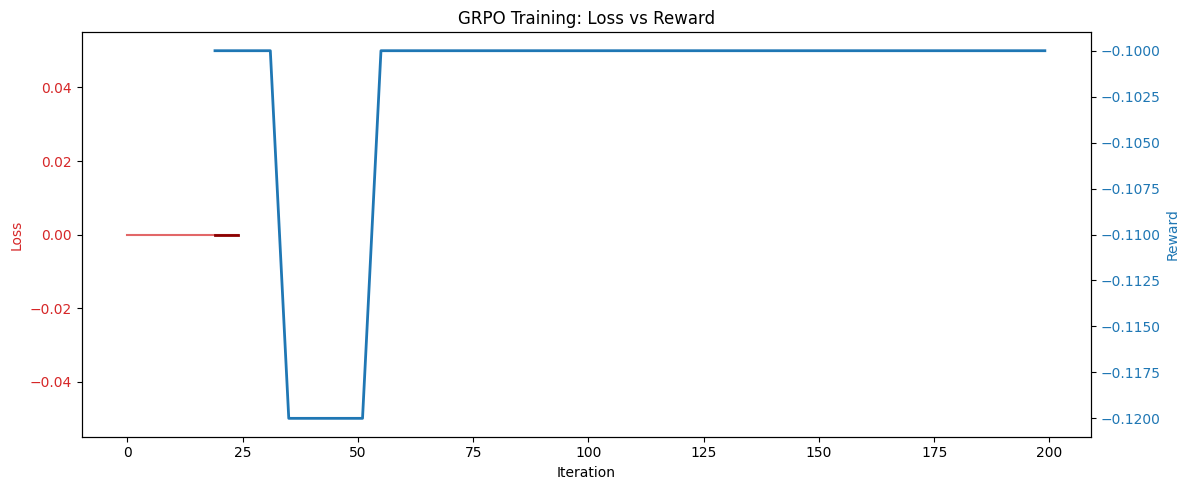

In [ ]:
"""
MLX GRPO Training for Sokoban
"""
import os
import numpy as np
import matplotlib.pyplot as plt
import mlx.optimizers as optim

# Import from your existing rl module
from core.microban import load_microban
from rl import (
    build_dataset,
    MLXGRPOConfig,
    setup_models,
    grpo_train_loop,
    quick_evaluation,
    debug_generation
)

print("="*60)
print("MLX GRPO for Sokoban")
print("="*60)

# ============================================================================
# Configuration
# ============================================================================

config = MLXGRPOConfig()
config.model_path = os.environ.get("NEMTRON_PATH")
config.repr_key = "13_ACTION_CENTRIC"
config.num_train_puzzles = 20
config.max_steps_per_puzzle = 30

# ============================================================================
# 1. Load puzzles
# ============================================================================

puzzles = load_microban("Microban.txt")
train_puzzles = [p for p in puzzles if p.num_boxes <= 3][:config.num_train_puzzles]
val_puzzles = [p for p in puzzles if p.num_boxes <= 3][config.num_train_puzzles:config.num_train_puzzles+10]

print(f"\nTraining puzzles: {len(train_puzzles)}")
print(f"Validation puzzles: {len(val_puzzles)}")

# ============================================================================
# 2. Build dataset (uses your build_dataset from rl)
# ============================================================================

print("\nBuilding training dataset...")
hf_dataset = build_dataset(
    puzzles=train_puzzles,
    repr_key=config.repr_key,
    max_steps_per_puzzle=config.max_steps_per_puzzle,
    verbose=True
)

# Convert to list for MLX
train_data = []
for item in hf_dataset:
    train_data.append({
        "prompt": item["prompt"],
        "board_ascii": item["board_ascii"],
        "optimal_move": item["optimal_move"],
        "optimal_cost": item["optimal_cost"],
    })

print(f"  Total training examples: {len(train_data)}")

sample = train_data[0]
print("="*60)
print("SAMPLE PROMPT (first 500 chars):")
print("="*60)
print(sample["prompt"])
print("...")
print("\nDoes it contain the board?")
print("  '####' in prompt:", '####' in sample["prompt"])
print("  '@' in prompt:", '@' in sample["prompt"])
print("  '$' in prompt:", '$' in sample["prompt"])

# ============================================================================
# 3. Build validation dataset
# ============================================================================

print("\nBuilding validation dataset...")
val_hf_dataset = build_dataset(
    puzzles=val_puzzles,
    repr_key=config.repr_key,
    max_steps_per_puzzle=config.max_steps_per_puzzle,
    verbose=True
)

val_data = []
for item in val_hf_dataset:
    val_data.append({
        "prompt": item["prompt"],
        "board_ascii": item["board_ascii"],
        "optimal_move": item["optimal_move"],
        "optimal_cost": item["optimal_cost"],
    })

print(f"  Total validation examples: {len(val_data)}")

# ============================================================================
# 4. Setup models
# ============================================================================

model, model_old, model_ref, tokenizer = setup_models(config)

# ============================================================================
# 5. Train
# ============================================================================

optimizer = optim.Adam(learning_rate=config.learning_rate)
model.train()

print("\n" + "="*60)
print("Starting GRPO Training")
print(f"  Iterations: {config.iters}")
print(f"  Group size: {config.group_size}")
print(f"  Batch size: {config.batch_size}")
print(f"  Learning rate: {config.learning_rate}")
print("="*60 + "\n")

debug_generation(model, tokenizer, train_data[0]["prompt"], config)

losses, rewards = grpo_train_loop(
    model=model,
    model_old=model_old,
    model_ref=model_ref,
    tokenizer=tokenizer,
    optimizer=optimizer,
    train_data=train_data,
    config=config
)

# ============================================================================
# 6. Plot results
# ============================================================================

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss', color='tab:red')
ax1.plot(losses, color='tab:red', alpha=0.7)
ax1.tick_params(axis='y', labelcolor='tab:red')

# Add smoothed loss
window = min(20, len(losses))
smoothed_loss = np.convolve(losses, np.ones(window)/window, mode='valid')
ax1.plot(range(window-1, len(losses)), smoothed_loss, color='darkred', linewidth=2, label='Smoothed Loss')

ax2 = ax1.twinx()
ax2.set_ylabel('Reward', color='tab:blue')
# Moving average of rewards
n = min(20, len(rewards))
moving_avg = np.convolve(rewards, np.ones(n)/n, mode='valid')
ax2.plot(range(n-1, len(rewards)), moving_avg, color='tab:blue', linewidth=2, label='Reward (MA)')
ax2.tick_params(axis='y', labelcolor='tab:blue')

# plt.title('GRPO Training: Loss vs Reward')
# fig.tight_layout()
# plt.savefig(config.output_dir / 'training_curves.png', dpi=150)
# plt.show()

# print(f"\n✓ Training curves saved to {config.output_dir / 'training_curves.png'}")

# # ============================================================================
# # 7. Save final model
# # ============================================================================

# model.save_weights(str(config.adapter_path / "adapters.safetensors"))
# print(f"✓ Adapters saved to {config.adapter_path / 'adapters.safetensors'}")

In [3]:
model.save_weights(str(config.adapter_path / "adapters.safetensors"))
print(f"✓ Adapters saved to {config.adapter_path / 'adapters.safetensors'}")

✓ Adapters saved to adapters/adapters.safetensors
